In [45]:
# CELL 1 — Imports
# Core
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import cv2

# ML / DL
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

# Clustering / eval
from sklearn.cluster import KMeans
from sklearn.metrics import classification_report, confusion_matrix

# Colab upload utility (works in Colab)
from google.colab import files

# Widgets (optional for mood dropdown)
import ipywidgets as widgets
from IPython.display import display, clear_output


In [46]:
# CELL 2 — Clone dataset if not already present
if not os.path.exists('clothing-dataset-small'):
    !git clone https://github.com/alexeygrigorev/clothing-dataset-small.git

# show structure
!ls -la clothing-dataset-small


total 36
drwxr-xr-x  6 root root 4096 Nov 29 01:03 .
drwxr-xr-x  1 root root 4096 Nov 29 01:50 ..
drwxr-xr-x  8 root root 4096 Nov 29 01:03 .git
-rw-r--r--  1 root root 7048 Nov 29 01:03 LICENSE
-rw-r--r--  1 root root 1061 Nov 29 01:03 README.md
drwxr-xr-x 12 root root 4096 Nov 29 01:03 test
drwxr-xr-x 12 root root 4096 Nov 29 01:03 train
drwxr-xr-x 12 root root 4096 Nov 29 01:03 validation


In [47]:
# CELL 3 — Data generators and paths
base_dir = 'clothing-dataset-small'
train_dir = os.path.join(base_dir, 'train')
val_dir = os.path.join(base_dir, 'validation')
test_dir = os.path.join(base_dir, 'test')

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.15,
    brightness_range=[0.8,1.2],
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)
test_datagen = ImageDataGenerator(preprocessing_function=preprocess_input)

train_generator = train_datagen.flow_from_directory(
    train_dir, target_size=(128,128), batch_size=32, class_mode='categorical'
)
val_generator = val_datagen.flow_from_directory(
    val_dir, target_size=(128,128), batch_size=32, class_mode='categorical'
)
test_generator = test_datagen.flow_from_directory(
    test_dir, target_size=(128,128), batch_size=32, class_mode='categorical', shuffle=False
)


Found 3068 images belonging to 10 classes.
Found 341 images belonging to 10 classes.
Found 372 images belonging to 10 classes.


In [48]:
# CELL 4 — Number of classes
num_classes = len(train_generator.class_indices)
class_indices = train_generator.class_indices
class_names = list(class_indices.keys())
print("Classes:", class_names)
print("Num classes:", num_classes)


Classes: ['dress', 'hat', 'longsleeve', 'outwear', 'pants', 'shirt', 'shoes', 'shorts', 'skirt', 't-shirt']
Num classes: 10


In [49]:
# CELL 5 — Build MobileNetV2 transfer learning model
base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(128,128,3))
base_model.trainable = False

x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
outputs = Dense(num_classes, activation='softmax')(x)

model = Model(inputs=base_model.input, outputs=outputs)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
model.summary()


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 128, 128,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 64, 64,    │        864 │ input_layer_2[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 64, 64,    │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 64, 64,    │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 64, 64,    │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 64, 64,    │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 64, 64,    │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 64, 64,    │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 64, 64,    │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 65, 65,    │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 32, 32,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 32, 32,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 32, 32,    │      2,304 │ block_1_depthwis

 Total params: 2,588,490 (9.87 MB)

 Trainable params: 330,506 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [50]:
from tensorflow.keras.models import load_model

# Load the previously saved model
model = load_model("moodcloset_model.h5")
print("Model loaded successfully!")


Model loaded successfully!


In [51]:
# CELL 6 — Train model
#history = model.fit(
   #train_generator,
    #validation_data=val_generator,
    #epochs=15
#)


In [52]:
# Save the trained model
model.save("moodcloset_model.h5")
print("Model saved!")


Model saved!


In [53]:
# CELL 7 — Evaluate on test set
test_loss, test_acc = model.evaluate(test_generator)
print(f"Test Accuracy: {test_acc*100:.2f}%")

y_pred = model.predict(test_generator)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = test_generator.classes

print("\nClassification Report:")
print(classification_report(y_true, y_pred_classes, target_names=class_names))

print("\nConfusion Matrix:")
print(confusion_matrix(y_true, y_pred_classes))


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


12/12 ━━━━━━━━━━━━━━━━━━━━ 7s 340ms/step - accuracy: 0.8473 - loss: 0.5089
Test Accuracy: 87.37%
12/12 ━━━━━━━━━━━━━━━━━━━━ 8s 523ms/step

Classification Report:
              precision    recall  f1-score   support

       dress       0.67      0.93      0.78        15
         hat       0.80      0.67      0.73        12
  longsleeve       0.82      0.82      0.82        72
     outwear       0.84      0.82      0.83        38
       pants       0.95      0.98      0.96        42
       shirt       0.65      0.65      0.65        26
       shoes       1.00      0.99      0.99        73
      shorts       0.88      0.93      0.90        30
       skirt       1.00      0.75      0.86        12
     t-shirt       0.92      0.88      0.90        52

    accuracy                           0.87       372
   macro avg       0.85      0.84      0.84       372
weighted avg       0.88      0.87      0.87       372


Confusion Matrix:
[[14  0  0  0  0  0  0  0  0  1]
 [ 0  8  0  1  0  3  0  0  

In [54]:
# CELL 8 — Define mood palettes and skin-tone palettes & outfit pairing logic

mood_to_colors = {
    "happy": ["yellow", "orange", "bright red"],
    "calm": ["pastel blue", "mint", "lavender"],
    "confident": ["black", "navy", "bold red"],
    "relaxed": ["white", "beige", "soft green"]
}

skin_tone_colors = {
    "warm": ["yellow", "orange", "peach", "warm red"],
    "cool": ["blue", "purple", "mint", "teal"],
    "neutral": ["white", "beige", "gray", "soft pink"]
}

# Outfit pairing mapping (input item -> recommendations categories)
# Map common dataset labels to generalized types (adjust names to your class labels)
clothing_matches = {
    # Use keys that match your class_names (case sensitive). Adjust if necessary.
    # Example mapping for common label names:
    "shirt": ["pants", "jacket", "sneakers"],
    "t-shirt": ["jeans", "jacket", "sneakers"],
    "pants": ["shirt", "sweater", "sneakers"],
    "jeans": ["t-shirt", "sweater", "boots"],
    "dress": ["heels", "cardigan", "handbag"],
    "coat": ["scarf", "boots", "gloves"],
    "shoes": ["jeans", "dress", "skirt"]
}

def get_outfit_categories_for(predicted_label):
    # Try exact match; if not found attempt lowercase key
    if predicted_label in clothing_matches:
        return clothing_matches[predicted_label]
    if predicted_label.lower() in clothing_matches:
        return clothing_matches[predicted_label.lower()]
    # fallback: return some general items
    return ["top", "bottom", "shoes"]


Upload the clothing image you want to classify (one file).


Saving Screenshot 2025-11-22 192525.png to Screenshot 2025-11-22 192525 (1).png
Clothing image uploaded: Screenshot 2025-11-22 192525 (1).png


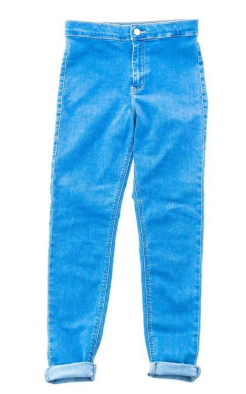

In [55]:
# CELL 9 — Upload clothing image
print("Upload the clothing image you want to classify (one file).")
uploaded_clothing = files.upload()

# Save the uploaded filename variable
clothing_image_path = None
for filename in uploaded_clothing.keys():
    clothing_image_path = filename
    print("Clothing image uploaded:", clothing_image_path)

# Display image
if clothing_image_path:
    display(Image.open(clothing_image_path))
else:
    print("No clothing image uploaded.")


In [56]:
# CELL 10 — Predict class and extract dominant colors
def predict_clothing_class(image_path):
    img = Image.open(image_path).convert('RGB').resize((128,128))
    arr = np.array(img)
    arr = np.expand_dims(arr, axis=0)
    arr = preprocess_input(arr)
    pred = model.predict(arr)
    idx = np.argmax(pred)
    label = class_names[idx]
    return label, pred[0]

def extract_dominant_colors_rgb(image_path, k=3):
    img = cv2.imread(image_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    img_small = cv2.resize(img, (64,64)).reshape(-1,3)
    kmeans = KMeans(n_clusters=k, random_state=0).fit(img_small)
    centers = kmeans.cluster_centers_.astype(int)
    # return centers as list of RGB tuples
    return [tuple(c) for c in centers]

if clothing_image_path:
    predicted_label, probs = predict_clothing_class(clothing_image_path)
    print("Predicted clothing label:", predicted_label)
    dominant_colors_rgb = extract_dominant_colors_rgb(clothing_image_path, k=3)
    print("Dominant clothing colors (RGB):", dominant_colors_rgb)
else:
    predicted_label = None
    dominant_colors_rgb = []


1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step
Predicted clothing label: pants
Dominant clothing colors (RGB): [(np.int64(252), np.int64(253), np.int64(254)), (np.int64(90), np.int64(177), np.int64(230)), (np.int64(26), np.int64(150), np.int64(224))]


Upload a selfie (face visible) for skin tone detection (one file).


Saving Screenshot 2025-11-25 001626.png to Screenshot 2025-11-25 001626 (1).png
Selfie uploaded: Screenshot 2025-11-25 001626 (1).png


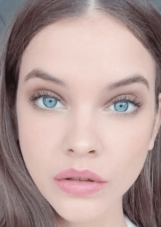

In [57]:
# CELL 11 — Upload selfie for skin tone detection
print("Upload a selfie (face visible) for skin tone detection (one file).")
uploaded_selfie = files.upload()

selfie_image_path = None
for filename in uploaded_selfie.keys():
    selfie_image_path = filename
    print("Selfie uploaded:", selfie_image_path)

if selfie_image_path:
    display(Image.open(selfie_image_path))
else:
    print("No selfie uploaded.")


In [58]:
# CELL 12 — Skin tone detection (automatic)
def detect_skin_region_and_average_rgb(image_path):
    # Simple approach: sample center region (assumes selfie has face roughly centered)
    img = Image.open(image_path).convert('RGB')
    img = img.resize((200,200))
    arr = np.array(img)
    h, w, _ = arr.shape
    cx, cy = w//2, h//2
    # central patch (rough area likely to include cheek/face)
    patch = arr[cy-40:cy+40, cx-30:cx+30]
    patch_flat = patch.reshape(-1,3)
    # KMeans to get dominant colors in patch
    kmeans = KMeans(n_clusters=2, random_state=0).fit(patch_flat)
    centers = kmeans.cluster_centers_.astype(int)
    # choose the lighter/more skin-like center by simple heuristic (R > G > B typical)
    # compute average center and return as RGB
    avg = np.mean(centers, axis=0).astype(int)
    return tuple(avg), centers

def classify_undertone_from_rgb(rgb_tuple):
    r, g, b = rgb_tuple
    if (r - b) > 15 and r > g:
        return "warm"
    elif (b - r) > 10:
        return "cool"
    else:
        return "neutral"

if selfie_image_path:
    avg_rgb, skin_centers = detect_skin_region_and_average_rgb(selfie_image_path)
    detected_undertone = classify_undertone_from_rgb(avg_rgb)
    print("Detected average face RGB:", avg_rgb)
    print("Detected skin undertone:", detected_undertone)
else:
    detected_undertone = None


Detected average face RGB: (np.int64(207), np.int64(178), np.int64(172))
Detected skin undertone: warm


In [59]:
# CELL 13 — Mood input (interactive dropdown)
mood_widget = widgets.Dropdown(
    options=['happy', 'calm', 'confident', 'relaxed'],
    value='happy',
    description='Mood:'
)
display(mood_widget)

# Let user select and then run next cell to get results


Dropdown(description='Mood:', options=('happy', 'calm', 'confident', 'relaxed'), value='happy')

In [60]:
# CELL 14 — Full outfit generation and top-N suggestions (fixed version)

def color_name_from_rgb(rgb):
    r, g, b = rgb
    if r>200 and g>180 and b<100:
        return "yellow"
    if r>200 and g<120 and b<120:
        return "red"
    if b>180 and r<140:
        return "blue"
    if g>160 and b>150:
        return "mint"
    if r>180 and g>100 and b<60:
        return "orange"
    if r>200 and g>200 and b>200:
        return "white"
    if r<70 and g<70 and b<70:
        return "black"
    return "color"


def generate_full_outfit_suggestions(predicted_label, dominant_colors_rgb, user_mood, undertone, top_n=5):
    mood_palette = mood_to_colors.get(user_mood, [])
    undertone_palette = skin_tone_colors.get(undertone, [])
    detected_clothing_color_names = [color_name_from_rgb(rgb) for rgb in dominant_colors_rgb]

    combined_ordered = detected_clothing_color_names + mood_palette + undertone_palette

    outfit_cats = get_outfit_categories_for(predicted_label)

    suggestions = []
    for item in outfit_cats:
        for color in combined_ordered:
            suggestions.append({"item": item, "color": color})
            if len(suggestions) >= top_n:
                break
        if len(suggestions) >= top_n:
            break

    return suggestions, combined_ordered, outfit_cats


# ---------- FIXED: This cell no longer runs automatically ----------
# User must call run_recommendation() manually AFTER choosing mood

def run_recommendation():
    if predicted_label is None:
        print("No predicted clothing item. Upload clothing image first.")
        return

    user_mood = mood_widget.value  # now read at execution time
    print("Using mood:", user_mood)

    suggestions, combined_palette, outfit_cats = generate_full_outfit_suggestions(
        predicted_label,
        dominant_colors_rgb,
        user_mood,
        detected_undertone,
        top_n=8
    )

    print("\n=== MoodCloset Full Outfit Suggestions ===")
    print(f"Predicted item: {predicted_label}")
    print(f"User mood: {user_mood}")
    print(f"Detected undertone: {detected_undertone}")

    print("\nCombined palette (priority):", combined_palette)

    print("\nSuggested outfit categories:", outfit_cats)

    print("\nTop suggestions:")
    for s in suggestions:
        print(f"- {s['color']} {s['item']}")

    # Show dominant color swatches
    try:
        fig, axs = plt.subplots(1, len(dominant_colors_rgb), figsize=(3*len(dominant_colors_rgb), 2))
        if len(dominant_colors_rgb) == 1:
            axs = [axs]
        for ax, rgb in zip(axs, dominant_colors_rgb):
            ax.imshow(np.ones((50,50,3), dtype=np.uint8) * np.array(rgb, dtype=np.uint8).reshape(1,1,3))
            ax.axis("off")
        plt.suptitle("Dominant clothing colors (RGB)")
        plt.show()
    except:
        pass

    print("\nRun finished.")


print("After selecting mood above, run:")
print("run_recommendation()")


After selecting mood above, run:
run_recommendation()


In [61]:
!pip install gradio


In [63]:

# CELL —  Gradio interface

import gradio as gr
import cv2
import numpy as np
from PIL import Image
import os

def _save_pil_to_bgr(pil_img, fname):
    """Save a PIL image to disk as BGR (OpenCV) JPEG"""
    arr = np.array(pil_img.convert("RGB"))
    bgr = cv2.cvtColor(arr, cv2.COLOR_RGB2BGR)
    cv2.imwrite(fname, bgr)

def moodcloset_app(clothing_img, selfie_img, mood):
    # Validate inputs
    if clothing_img is None:
        return "⚠️ Please upload a clothing image."
    if selfie_img is None:
        return "⚠️ Please upload a selfie image."
    if mood is None or mood == "":
        return "⚠️ Please select a mood."

    # Save temporary files
    cloth_path = "temp_cloth.jpg"
    selfie_path = "temp_selfie.jpg"
    try:
        _save_pil_to_bgr(clothing_img, cloth_path)
        _save_pil_to_bgr(selfie_img, selfie_path)
    except Exception as e:
        return f"Error saving images: {e}"

    # 1) Clothing classification (uses your predict_clothing_class which expects a path)
    try:
        predicted_label, probs = predict_clothing_class(cloth_path)
    except Exception as e:
        return f"Error during clothing classification: {e}"

    # 2) Dominant colors (uses your extract_dominant_colors_rgb which accepts a path)
    try:
        dominant_colors_rgb = extract_dominant_colors_rgb(cloth_path, k=3)
    except Exception as e:
        dominant_colors_rgb = []

    # 3) Skin tone detection (uses your detect_skin_region_and_average_rgb)
    try:
        avg_rgb, centers = detect_skin_region_and_average_rgb(selfie_path)
        detected_undertone = classify_undertone_from_rgb(avg_rgb)
    except Exception as e:
        # Fallback if detection fails
        detected_undertone = "neutral"

    # 4) Outfit pairing and palettes
    outfit_cats = get_outfit_categories_for(predicted_label)
    mood_palette = mood_to_colors.get(mood, [])
    skin_palette = skin_tone_colors.get(detected_undertone, [])
    combined_palette = mood_palette + skin_palette

    # 5) Build suggestions (limit to up to 8 suggestions)
    suggestions = []
    for item in outfit_cats:
        for color in combined_palette:
            suggestions.append(f"{color} {item}")
            if len(suggestions) >= 8:
                break
        if len(suggestions) >= 8:
            break

    # 6) Build nice markdown output
    md = []
    md.append("### 👗 MoodCloset Full Outfit Recommendation\n")
    md.append(f"**Detected clothing:** `{predicted_label}`  ")
    md.append(f"**Detected skin undertone:** `{detected_undertone}`  ")
    md.append(f"**Mood:** `{mood}`  \n")

    if dominant_colors_rgb:
        # show RGB tuples as simple swatches & hex-like text
        swatches = []
        for c in dominant_colors_rgb:
            r,g,b = c
            hexc = "#{:02x}{:02x}{:02x}".format(int(r),int(g),int(b))
            swatches.append(f"`{(r,g,b)}` {hexc}")
        md.append("**Dominant colors (RGB / HEX):**  ")
        md.append("  \n".join(swatches) + "  \n")
    else:
        md.append("**Dominant colors:** Not detected  \n")

    md.append("**Suggested outfit pieces:**  ")
    md.append(", ".join(outfit_cats) + "  \n")

    md.append("**Top suggestions (item + color):**  ")
    for s in suggestions[:8]:
        md.append(f"- {s}")

    # Clean up temp files (non-critical)
    try:
        if os.path.exists(cloth_path): os.remove(cloth_path)
        if os.path.exists(selfie_path): os.remove(selfie_path)
    except:
        pass

    return "\n".join(md)


# Build the Gradio UI
with gr.Blocks() as demo:
    gr.Markdown("# 👗 MoodCloset — Smart Outfit Recommendation")

    with gr.Row():
        clothing_input = gr.Image(
            type="pil",
            label="Upload clothing image",
            sources=["upload"],      # <-- FIXED
            interactive=True
        )

        selfie_input = gr.Image(
            type="pil",
            label="Upload selfie (face visible)",
            sources=["upload"],      # <-- FIXED
            interactive=True
        )

    mood_input = gr.Dropdown(
        ["happy", "calm", "confident", "relaxed"],
        label="Select your mood",
        value="happy"
    )

    recommend_btn = gr.Button("Get Full Outfit Recommendation")
    output_md = gr.Markdown("")

    recommend_btn.click(
        fn=moodcloset_app,
        inputs=[clothing_input, selfie_input, mood_input],
        outputs=output_md
    )

demo.launch(share=True)



Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://bd3627108f83735bf1.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
